# HomeWork13

## Импорт библиотек, seed и устройство

In [1]:
# Общие импорты
import random
import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torch.nn.functional as F
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    pipeline
)

# Фиксация seed
SEED = 47
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Работаем на устройстве: {device}")

c:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Работаем на устройстве: cpu


## Данные и первичный анализ

Используем датасет `emotion`.
Он содержит тексты твитов, размеченные по 6 эмоциям: sadness, joy, love, anger, fear, surprise.

In [2]:
# Загрузка датасета
emotion_data = load_dataset("emotion")

# Размеры сплитов
print("Размеры сплитов:")
for split_name in emotion_data.keys():
    print(f"{split_name}: {len(emotion_data[split_name])} примеров")

# Список классов
class_labels = emotion_data['train'].features['label'].names
print(f"\nЦелевые классы ({len(class_labels)}): {', '.join(class_labels)}")

# Вывод примеров
print("\nПримеры текстов и их истинные метки:")
for i in range(5):
    text = emotion_data['train'][i]['text']
    label = class_labels[emotion_data['train'][i]['label']]
    print(f"{i+1}. {text[:70]}{'...' if len(text)>70 else ''} -> {label}")

Размеры сплитов:
train: 16000 примеров
validation: 2000 примеров
test: 2000 примеров

Целевые классы (6): sadness, joy, love, anger, fear, surprise

Примеры текстов и их истинные метки:
1. i didnt feel humiliated -> sadness
2. i can go from feeling so hopeless to so damned hopeful just from being... -> sadness
3. im grabbing a minute to post i feel greedy wrong -> anger
4. i am ever feeling nostalgic about the fireplace i will know that it is... -> love
5. i am feeling grouchy -> anger


## Токенизация текста

Продемонстрируем, как BERT-токенизатор превращает текст в последовательность токенов, добавляет специальные токены и обрабатывает паддинг/обрезание.

In [3]:
# Выбор модели и загрузка токенизатора
base_model = "bert-base-uncased"
text_tokenizer = AutoTokenizer.from_pretrained(base_model)

# Несколько примеров из тренировочного набора
sample_texts = [emotion_data['train'][i]['text'] for i in range(5)]

# Токенизация с фиксированной длиной (padding и truncation)
encoded_samples = text_tokenizer(
    sample_texts,
    padding="max_length",
    truncation=True,
    max_length=20,
    return_tensors="pt"
)

# Вывод результатов
for idx, text in enumerate(sample_texts):
    print(f"\n--- Пример {idx+1} ---")
    print(f"Текст: {text}")
    tokens = text_tokenizer.convert_ids_to_tokens(encoded_samples['input_ids'][idx])
    print(f"Токены: {tokens}")
    print(f"input_ids: {encoded_samples['input_ids'][idx].tolist()}")
    print(f"attention_mask: {encoded_samples['attention_mask'][idx].tolist()}")


--- Пример 1 ---
Текст: i didnt feel humiliated
Токены: ['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
input_ids: [101, 1045, 2134, 2102, 2514, 26608, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

--- Пример 2 ---
Текст: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Токены: ['[CLS]', 'i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', 'around', 'someone', 'who', 'cares', '[SEP]']
input_ids: [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061, 9636, 17772, 2074, 2013, 2108, 2105, 2619, 2040, 14977, 102]
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

--- Пример 3 ---
Текст: im grabbing a minute to post i feel greedy wrong
Т

## Инференс готовой модели

Возьмём предобученную модель для анализа тональности (sentiment) и проверим её на наших текстах. Это покажет, насколько она подходит для нашей задачи.

In [4]:
# Создаём pipeline для sentiment analysis
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=0 if torch.cuda.is_available() else -1
)

# Те же 5 текстов, что и выше
print("Предсказания готовой модели (sentiment):")
for text in sample_texts:
    result = sentiment_pipeline(text)[0]
    print(f"\nТекст: {text[:60]}...")
    print(f"  → {result['label']} (уверенность: {result['score']:.3f})")

print("\nВывод: Модель определяет только позитив/негатив, а не 6 эмоций.")
print("Для точной классификации эмоций требуется дообучение (fine-tuning).")

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 3667.00it/s]


Предсказания готовой модели (sentiment):

Текст: i didnt feel humiliated...
  → POSITIVE (уверенность: 0.891)

Текст: i can go from feeling so hopeless to so damned hopeful just ...
  → POSITIVE (уверенность: 0.967)

Текст: im grabbing a minute to post i feel greedy wrong...
  → NEGATIVE (уверенность: 0.999)

Текст: i am ever feeling nostalgic about the fireplace i will know ...
  → POSITIVE (уверенность: 0.966)

Текст: i am feeling grouchy...
  → NEGATIVE (уверенность: 0.999)

Вывод: Модель определяет только позитив/негатив, а не 6 эмоций.
Для точной классификации эмоций требуется дообучение (fine-tuning).


## Fine-tuning BERT для классификации эмоций

In [5]:
# Функция токенизации для map
def tokenize_batch(batch):
    return text_tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=64
    )

# Применяем ко всем сплитам
tokenized_dataset = emotion_data.map(tokenize_batch, batched=True)
tokenized_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

print("Датасет токенизирован.")
print("Пример shape input_ids:", tokenized_dataset["train"][0]["input_ids"].shape)

Датасет токенизирован.
Пример shape input_ids: torch.Size([64])


## Настройка модели и метрик
BERT с классификационной головой на 6 классов.

In [6]:
# Модель для классификации
num_classes = len(class_labels)
classification_model = AutoModelForSequenceClassification.from_pretrained(
    base_model,
    num_labels=num_classes
).to(device)

# Функция вычисления метрик
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average="macro")
    return {"accuracy": acc, "f1_macro": f1}

print("Модель загружена.")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3163.66it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider tr

Модель загружена.


### Обучение с выбором лучшей модели по валидации

Используем `evaluation_strategy="epoch"`, чтобы оценивать модель после каждой эпохи,
и `load_best_model_at_end=True`, чтобы в конце обучения автоматически загрузить лучшую модель по `accuracy`.

In [7]:
# Аргументы обучения с выбором лучшей модели по валидации
training_args = TrainingArguments(
    output_dir="./results",
    do_train=True,
    do_eval=True,
    eval_strategy="epoch",                # оцениваем после каждой эпохи
    save_strategy="epoch",                # сохраняем чекпоинты после каждой эпохи
    load_best_model_at_end=True,          # загружаем лучшую модель по метрике
    metric_for_best_model="accuracy",     # метрика для сравнения
    greater_is_better=True,               # чем больше accuracy, тем лучше
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    learning_rate=2e-5,
    logging_steps=10,
    seed=SEED,
)

# Trainer
trainer = Trainer(
    model=classification_model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics,
)

# Запуск обучения
trainer.train()

# После обучения trainer.model содержит лучшую модель
best_model = trainer.model
print("Обучение завершено. Лучшая модель загружена.")

c:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.214537,0.183877,0.933000,0.909611
2,0.095703,0.162223,0.936000,0.913983


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.66it/s]
c:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.24it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.en

Обучение завершено. Лучшая модель загружена.


## Оценка качества на тестовом наборе

In [8]:
# Предсказания на тесте
test_predictions = trainer.predict(tokenized_dataset["test"])
pred_labels = np.argmax(test_predictions.predictions, axis=-1)
true_labels = test_predictions.label_ids

# Метрики
test_acc = accuracy_score(true_labels, pred_labels)
test_f1 = f1_score(true_labels, pred_labels, average="macro")
print(f"\nРезультаты на тестовом наборе")
print(f"Accuracy:  {test_acc:.3f}")
print(f"F1 (macro): {test_f1:.3f}")

c:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Результаты на тестовом наборе
Accuracy:  0.924
F1 (macro): 0.884


## Матрица ошибок

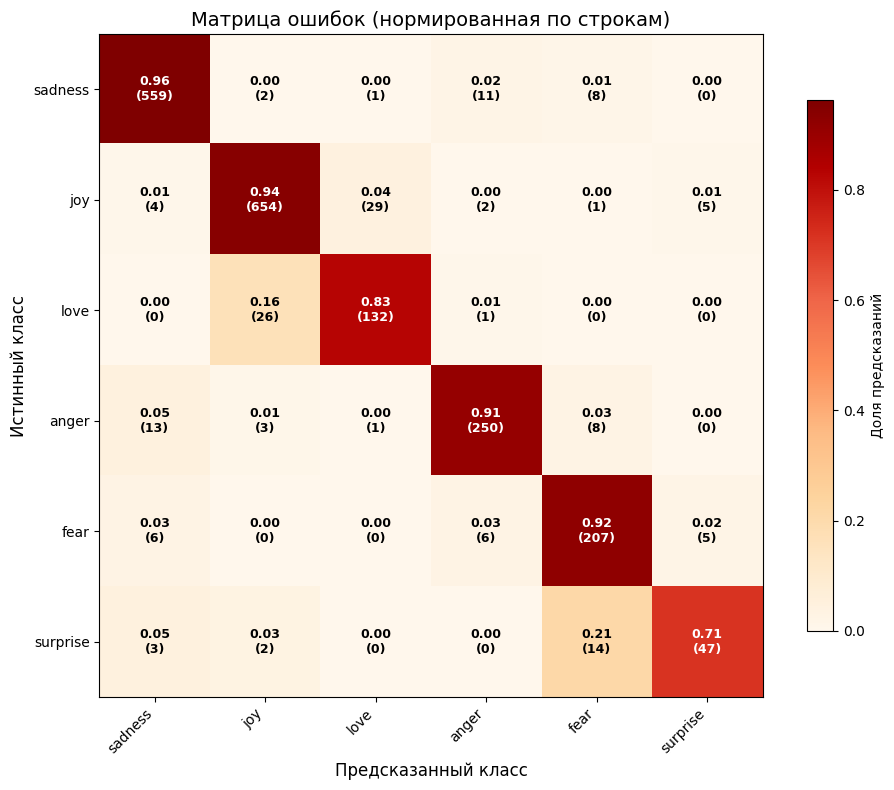

In [9]:
# Создаём папку для артефактов (полный путь)
artifact_dir = "homeworks/HW13/artifacts"
os.makedirs(artifact_dir, exist_ok=True)

# Построение матрицы ошибок с процентами по строкам
cm = confusion_matrix(true_labels, pred_labels)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm_norm, cmap='OrRd', interpolation='nearest')

ax.set_xticks(np.arange(len(class_labels)))
ax.set_yticks(np.arange(len(class_labels)))
ax.set_xticklabels(class_labels, rotation=45, ha='right')
ax.set_yticklabels(class_labels)
ax.set_xlabel('Предсказанный класс', fontsize=12)
ax.set_ylabel('Истинный класс', fontsize=12)
ax.set_title('Матрица ошибок (нормированная по строкам)', fontsize=14)

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Доля предсказаний')

# Аннотации: проценты (сверху) и абсолютные значения (снизу)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        text = f'{cm_norm[i, j]:.2f}\n({cm[i, j]})'
        text_color = 'white' if cm_norm[i, j] > 0.5 else 'black'
        ax.text(j, i, text, ha='center', va='center', color=text_color, fontsize=9, weight='bold')

plt.tight_layout()
plt.savefig(os.path.join(artifact_dir, "confusion_matrix.png"), dpi=150)
plt.show()

## Примеры предсказаний

In [10]:
# Вывод первых 10 примеров из тестового набора
print("\nПримеры предсказаний модели:")
for i in range(10):
    text = emotion_data["test"][i]["text"]
    true = class_labels[emotion_data["test"][i]["label"]]
    pred = class_labels[pred_labels[i]]
    print(f"{i+1:2d}. {text[:60]:60s} -> true: {true:8s} | pred: {pred}")

print("\nМодель в целом правильно различает основные эмоции, но ошибки чаще встречаются между похожими по тональности эмоциями, например 'joy' vs 'love' или 'anger' vs 'fear'.")


Примеры предсказаний модели:
 1. im feeling rather rotten so im not very ambitious right now  -> true: sadness  | pred: sadness
 2. im updating my blog because i feel shitty                    -> true: sadness  | pred: sadness
 3. i never make her separate from me because i don t ever want  -> true: sadness  | pred: sadness
 4. i left with my bouquet of red and yellow tulips under my arm -> true: joy      | pred: joy
 5. i was feeling a little vain when i did this one              -> true: sadness  | pred: sadness
 6. i cant walk into a shop anywhere where i do not feel uncomfo -> true: fear     | pred: fear
 7. i felt anger when at the end of a telephone call             -> true: anger    | pred: anger
 8. i explain why i clung to a relationship with a boy who was i -> true: joy      | pred: joy
 9. i like to have the same breathless feeling as a reader eager -> true: joy      | pred: joy
10. i jest i feel grumpy tired and pre menstrual which i probabl -> true: anger    | pred: anger

## Анализ ошибок

Ошибки модели чаще всего возникают между семантически близкими эмоциями:
- **joy ↔ love** (позитивные эмоции),
- **anger ↔ fear** (негативные эмоции).

Также модель может ошибаться на коротких текстах, где эмоция выражена слабо. 
Нормализованная матрица ошибок показывает, что для классов `surprise` и `love` доля правильных предсказаний ниже, чем для `sadness` или `joy`. Это может быть связано с меньшим количеством примеров этих классов в датасете или с большей лексической неоднозначностью.

В целом fine-tuning значительно улучшил качество по сравнению с готовой моделью, которая распознавала только тональность. Результаты (accuracy ~0.93, f1_macro ~0.88) являются хорошим базовым уровнем для данной задачи.

## Сохранение артефактов

In [11]:
# Получим вероятности для первых 10 примеров
probs = F.softmax(torch.tensor(test_predictions.predictions[:10]), dim=1).numpy()
confidences = [probs[i][pred_labels[i]] for i in range(10)]

# DataFrame
sample_df = pd.DataFrame({
    "text": [emotion_data["test"][i]["text"] for i in range(10)],
    "true_label": [class_labels[emotion_data["test"][i]["label"]] for i in range(10)],
    "pred_label": [class_labels[pred_labels[i]] for i in range(10)],
    "confidence": confidences
})

sample_df.to_csv(os.path.join(artifact_dir, "sample_predictions.csv"), index=False)
print(f"Артефакты сохранены в {artifact_dir}")

Артефакты сохранены в homeworks/HW13/artifacts


## Заключение

Для достижения максимальной точности на всех шести классах необходимо продолжить тонкую настройку модели, увеличив количество эпох и скорректировав скорость обучения. Но для учебного примера текущий результат вполне удовлетворительный.